Helper functions

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import os
import seaborn as sns
import pandas as pd
import torch
from scipy.integrate import solve_ivp
from collections.abc import Callable
from typing import Tuple, Optional
from scipy.integrate import odeint

# Helper: wrap a PyTorch model that takes a torch tensor of shape (N,) or (N,1)
def make_torch_wrapper(pt_model, device="cpu", batch_dim=False):
    """
    Wrap a PyTorch model so it can be called as a numpy function u -> out (numpy array).
    - pt_model should accept a torch tensor of shape (N,) or (N,1) and return (N,) or (N,1)
    - device: 'cpu' or 'cuda'
    - batch_dim: if True, the model expects input shape (batch, N) or similar; keep False for elementwise
    Returns: callable(u_numpy) -> numpy array
    """
    pt_model.to(device)
    pt_model.eval()
    def wrapper(u_np: np.ndarray) -> np.ndarray:
        # Convert to torch tensor
        with torch.no_grad():
            u_t = torch.from_numpy(u_np.astype(np.float32)).to(device)
            # If model expects shape (N,1), reshape
            if u_t.ndim == 1:
                u_t_in = u_t.unsqueeze(1)  # (N,1)
            else:
                u_t_in = u_t
            out = pt_model(u_t_in)
            # If out has shape (N,1) or (N,), convert to 1D numpy
            out_np = out.detach().cpu().numpy()
            out_np = out_np.reshape(u_np.shape)
        return out_np
    return wrapper

# -------------------------------------------------------------------
# Barenblatt (Barenblatt-Kompaneets-Zeldovich) profile for
#    u_t = d/dx(3 u^2 u_x)  <=>  u_t = (u^3)_{xx}  (m = 3)
# -------------------------------------------------------------------
def barenblatt_pme_m3(x, t, M, m):
    """
    Barenblatt solution for u_t = (u^3)_{xx} in 1D with total mass M.
    Returns u(x,t). Requires t > 0.
    """
    if t <= 0:
        raise ValueError("t must be > 0 for self-similar formula")

    m = 3.0
    # similarity exponents
    alpha = 1.0 / (m + 1.0)   # = 1/4
    beta  = alpha             # = 1/4

    # constant B from the standard Barenblatt formula
    bb = (m - 1.0) / (2.0 * m) * beta   # = 1/12 for m=3

    # b determined by the mass M (1D)
    b = (2.0 * M * np.sqrt(bb)) / np.pi  # = M / (pi * sqrt(3)) when m=3

    xi = np.asarray(x) / (t ** beta)
    inner = b - bb * xi**2

    # profile raised to 1/(m-1) -> 1/2 (sqrt) for m=3
    ff = np.sqrt(np.maximum(inner, 0.0))

    return (t ** (-alpha)) * ff

# reconstruct the solution using the learned NN 'D_model' at the training points (x_train, t_train)
def recon_solution(x_train, t_train, D_model, u_NN_IC):
    D_callable = make_torch_wrapper(D_model, device='cpu')
    u_sim = simulate_pde(x_train, u_NN_IC, D_callable,
                       t_span=(t_train[0], t_train[-1]),
                       t_eval=t_train,
                       integrator="RK45")
    return u_sim

# Simulate the PDE u_t = (D(u) u_x)_x with Neumann BCs using method of lines and solve_ivp
def simulate_pde(x: np.ndarray,
                 IC: np.ndarray,
                 D_callable: Callable[[np.ndarray], np.ndarray],
                 t_span: Tuple[float, float] = (0.0, 20.0),
                 t_eval: np.ndarray = None,
                 integrator: str = "RK45",
                 rtol: float = 1e-6,
                 atol: float = 1e-8,
                 save_path: str = None):
    """
    Simulate FKPP with BC: u_x=0 at boundaries (note: not no-flux BCs!).
    Inputs:
      x           : 1D grid (numpy array)
      IC          : initial condition (numpy array same length as x)
      D_callable  : function(u_array) -> D_array (same length as u)
      t_span      : (t0, tf)
      t_eval      : times to evaluate solution; default 201 points between t0 and tf
      integrator  : "RK45" or "BDF" etc; BDF recommended if stiff
      rtol, atol  : tolerances for solve_ivp
      save_path   : optional path to save final u as npy
    Returns:
      sol : the SciPy OdeResult-like object from solve_ivp (sol.y shape (N, len(t_eval)))
    """
    
    x = np.asarray(x)
    N = x.size
    dx = x[1] - x[0]
    assert IC.shape == x.shape, "IC must match x shape"
    if t_eval is None:
        t_eval = np.linspace(t_span[0], t_span[1], 201)

    def rhs(t, u_vec):
        u = np.asarray(u_vec)

        # Evaluate D at nodes
        Dn = D_callable(u)
        if Dn.shape != u.shape:
            raise ValueError("D_callable must return array of same shape as u")

        # Build ghost-point extension for Neumann BCs: u_x = 0
        u_ext = np.empty(N + 2, dtype=u.dtype)
        u_ext[1:-1] = u
        u_ext[0] = u[1]      # left ghost cell: u_{-1} = u_1
        u_ext[-1] = u[-2]    # right ghost cell: u_N = u_{N-2}

        # Extend D consistently
        Dn_ext = np.empty(N + 2, dtype=Dn.dtype)
        Dn_ext[1:-1] = Dn
        Dn_ext[0] = Dn[1]
        Dn_ext[-1] = Dn[-2]

        # D at interfaces
        D_half = 0.5 * (Dn_ext[:-1] + Dn_ext[1:])   # length N+1

        # Fluxes at interfaces
        flux = D_half * (u_ext[1:] - u_ext[:-1]) / dx   # length N+1

        # Divergence at physical nodes
        diffusion_term = (flux[1:] - flux[:-1]) / dx

        return diffusion_term
        
    sol = solve_ivp(rhs, t_span, IC, method=integrator, t_eval=t_eval, rtol=rtol, atol=atol)

    if not sol.success:
        print("Warning: solver reported failure:", sol.message)
    if save_path is not None:
        np.save(save_path, sol.y[:, -1])
        print(f"Saved final state to {save_path}")

    return sol.y.T


Plot formatting & setups

In [2]:
# plot formatting
plt.rcParams['font.family'] = 'overall_overall_times New Roman'
plt.rcParams['text.usetex'] = True
plt.rcParams['font.family'] = 'serif'
plt.rcParams['axes.labelweight'] = 'bold'  # Bold axis labels
plt.rcParams['axes.titleweight'] = 'bold'  # Bold title
plt.rcParams['font.weight'] = 'bold'
plt.rcParams['font.size'] = str(20)
plt.rcParams['lines.linewidth'] = 2
alpha_val = 0.4

# epochs for training history
epoch_hist = np.arange(0, 4001, 1)

# time resolution
Nt, t_end, t_min = 7, 4.5, 0.5
t_train = np.linspace(t_min, t_end, Nt)

# spatial resolutions
L = 7.0
x_min, x_max = -L, L
dx= 0.04
x_train = np.arange(x_min, x_max+dx, dx)
Nx = len(x_train)

# Barenblatt solution profile: 
m = 3.0        # D(u) = mu^{m-1}
M = 3.0        # total mass
u_true = np.array([barenblatt_pme_m3(x_train, t, M, m) for t in t_train])
u_min_np, u_max_np = u_true.min(), u_true.max()
U_grid= np.linspace(u_min_np, u_max_np, Nx)

D_true = m * (U_grid ** (m - 1))

# the variances we used 
variances = [0.0, 0.01, 0.001]
seed = 2

NumRep = 10

top_load_folder = '../ARCresults/Diffusion_nonlinear_complexM3.0/'
top_save_folder = '../Figures/Fig5/'

subfolders = ['loss_weightings_var0.0/', 'loss_weightings_var0.01/', 'loss_weightings_var0.001/']

w_PDEs = [1e-4, 1e-3, 1e-2, 1e-1, 1.0, 1e1, 1e2, 1e3]
w_PDEs1 = [1e-4, 1e-1, 1e3]
indices = [0, 3, 7]
weight_u, weight_BC = 1.0, 1e-3
colors1 = sns.color_palette("Set2", len(w_PDEs1))
colors = sns.color_palette("Set1", 2)


alpha_val = 0.4

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

### Plot: weighted validation data loss versus pde loss over epochs

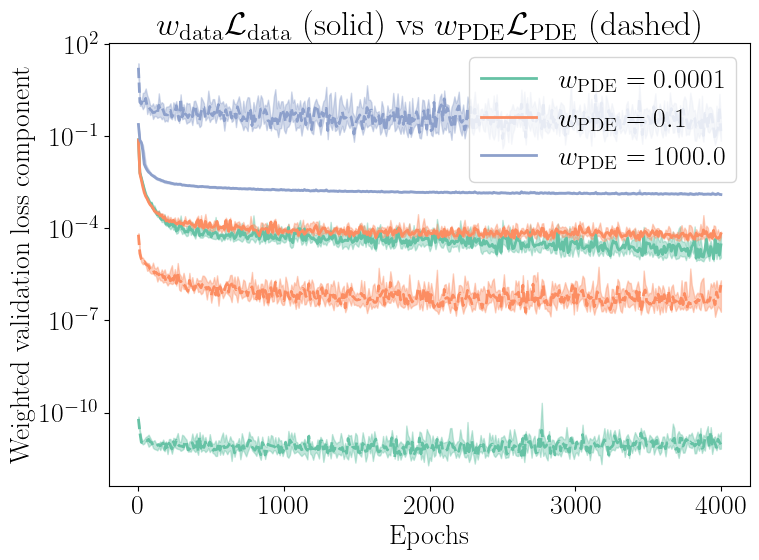

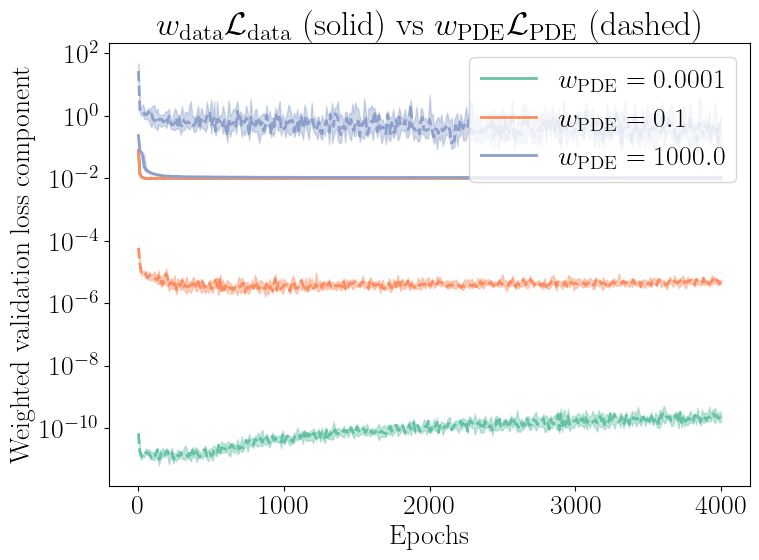

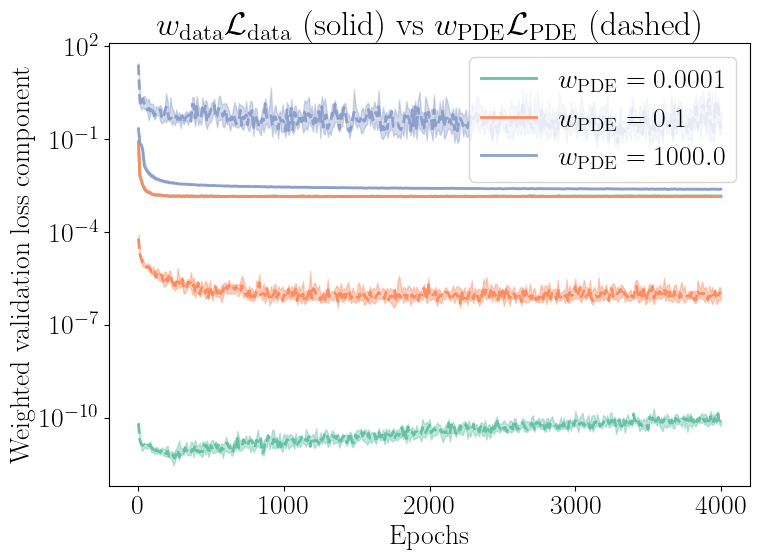

In [3]:
# subsample epochs every 10 epochs for plotting
epoch_subsampled = epoch_hist[::10]

for var, subfolder in zip(variances, subfolders):

    load_dir = top_load_folder + subfolder
    save_dir = top_save_folder + f'var{var}/'

    fig1, ax1 = plt.subplots(figsize=(8, 6))

    for wpde_ind, pde_weight in enumerate(w_PDEs1):

        val_pdeloss_S = np.load(load_dir + f'data1.0_PDE{pde_weight}_BC0.0/val_pdeloss_S.npy', allow_pickle=True)
        val_uloss_S = np.load(load_dir + f'data1.0_PDE{pde_weight}_BC0.0/val_uloss_S.npy', allow_pickle=True)
        val_BCloss_S = np.load(load_dir + f'data1.0_PDE{pde_weight}_BC0.0/val_BCloss_S.npy', allow_pickle=True)
        val_pdeloss_S, val_uloss_S, val_BCloss_S = np.asarray(val_pdeloss_S, dtype=float), np.asarray(val_uloss_S, dtype=float), np.asarray(val_BCloss_S, dtype=float)
    
        # weighted validation data loss
        val_uloss_S = weight_u * val_uloss_S
        median_data_loss = np.median(val_uloss_S, axis=0)
        q1_data_loss = np.percentile(val_uloss_S, 25, axis=0)
        q3_data_loss = np.percentile(val_uloss_S, 75, axis=0)
        ax1.plot(epoch_subsampled, median_data_loss[::10], color=colors1[wpde_ind], label=rf'$w_{{\mathrm{{PDE}}}}={pde_weight}$')
        ax1.fill_between(epoch_subsampled, q1_data_loss[::10], q3_data_loss[::10], color=colors1[wpde_ind], alpha=alpha_val)

        # weighted validation PDE loss
        val_pdeloss_S = pde_weight * val_pdeloss_S
        median_pde_loss = np.median(val_pdeloss_S, axis=0)
        q1_pde_loss = np.percentile(val_pdeloss_S, 25, axis=0)
        q3_pde_loss = np.percentile(val_pdeloss_S, 75, axis=0)
        ax1.plot(epoch_subsampled, pde_weight * median_pde_loss[::10], color=colors1[wpde_ind], linestyle='--')
        ax1.fill_between(epoch_subsampled, pde_weight * q1_pde_loss[::10], pde_weight * q3_pde_loss[::10], color=colors1[wpde_ind], alpha=alpha_val)

    ax1.set_yscale('log')
    ax1.set_xlabel('Epochs')
    ax1.set_ylabel('Weighted validation loss component')
    ax1.set_title(r'$w_{\mathrm{data}}\mathcal{L}_{\mathrm{data}}$ (solid) vs $w_{\mathrm{PDE}}\mathcal{L}_{\mathrm{PDE}}$ (dashed)')
    ax1.legend(loc='upper right')
    fig1.tight_layout()
    
    fig1.savefig(save_dir + f'weightedtotal_valLoss_var{var}.svg', format='svg', bbox_inches='tight')


Loop through w_PDEs to obtain store u_reconstr, L2RE of u_NN and u_reconstr

In [4]:
for var, subfolder in zip(variances, subfolders):

    noise_level = np.sqrt(var)
    print(f"Processing noise level {noise_level}...")

    load_dir = top_load_folder + subfolder
    save_dir = top_save_folder + f'var{var}/'

    np.random.seed(seed)
    additive_noise = noise_level * np.random.randn(*u_true.shape)
    u_true_noisy_IC = u_true + additive_noise

    errorS_uNN, errorS_u_reconstr = [], []
    u_reconstr_all = []
    
    for pde_weight in w_PDEs:
        print(f"  Processing PDE weight {pde_weight}...")

        err_u_reconstr, err_u_NN = [], []
        u_reconstr = []

        u_netS = np.load(load_dir + f'data1.0_PDE{pde_weight}_BC0.0/u_predS.npy')

        for rep in range(NumRep):
            u_NN = u_netS[rep, :, :]
            l2re_u = np.sqrt(np.sum((u_NN - u_true)**2)) / np.sqrt(np.sum(u_true**2))
            err_u_NN.append(l2re_u)

            # load learnt D models
            D_model = torch.load(load_dir + f'data1.0_PDE{pde_weight}_BC0.0/Iter{rep}/D_net_best_Iter{rep}.pth', map_location=torch.device('cpu'), weights_only=False)

            # ------------------ YY -----------------
            # use the learnt u_NN at t=0 as the initial condition to reconstruct the solution
            u_NN_IC = u_NN[0, :]
            u_sim = recon_solution(x_train, t_train, D_model, u_NN_IC)
            u_reconstr.append(u_sim)
            l2re_u_predicted = np.sqrt(np.sum((u_sim - u_true)**2)) / np.sqrt(np.sum(u_true**2))
            err_u_reconstr.append(l2re_u_predicted)

        errorS_u_reconstr.append(err_u_reconstr)
        errorS_uNN.append(err_u_NN)
        u_reconstr_all.append(u_reconstr)

    errorS_uNN = np.array(errorS_uNN)
    errorS_u_reconstr = np.array(errorS_u_reconstr)
    u_reconstr_all = np.array(u_reconstr_all)

    # save
    np.save(save_dir + 'errorS_uNN.npy', errorS_uNN)
    np.save(save_dir + 'errorS_u_reconstr.npy', errorS_u_reconstr)
    np.save(save_dir + 'u_reconstr_all.npy', u_reconstr_all)

Processing noise level 0.0...
  Processing PDE weight 0.0001...
  Processing PDE weight 0.001...
  Processing PDE weight 0.01...
  Processing PDE weight 0.1...
  Processing PDE weight 1.0...
  Processing PDE weight 10.0...
  Processing PDE weight 100.0...
  Processing PDE weight 1000.0...
Processing noise level 0.1...
  Processing PDE weight 0.0001...
  Processing PDE weight 0.001...
  Processing PDE weight 0.01...
  Processing PDE weight 0.1...
  Processing PDE weight 1.0...
  Processing PDE weight 10.0...
  Processing PDE weight 100.0...
  Processing PDE weight 1000.0...
Processing noise level 0.03162277660168379...
  Processing PDE weight 0.0001...
  Processing PDE weight 0.001...
  Processing PDE weight 0.01...
  Processing PDE weight 0.1...
  Processing PDE weight 1.0...
  Processing PDE weight 10.0...
  Processing PDE weight 100.0...
  Processing PDE weight 1000.0...


### Plot: L2RE for u_NN and u_reconstr across different w_PDEs

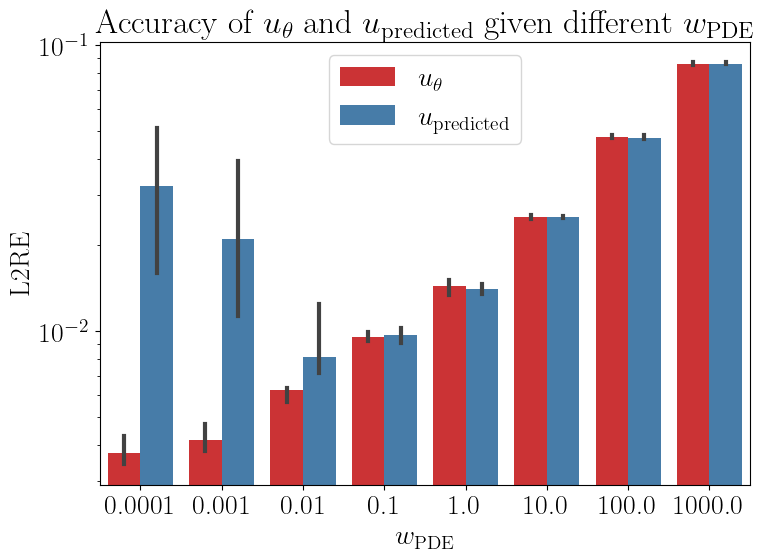

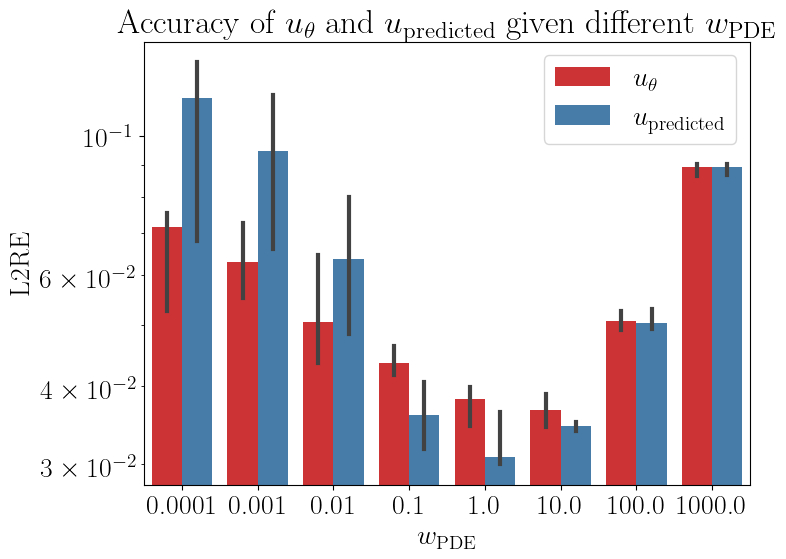

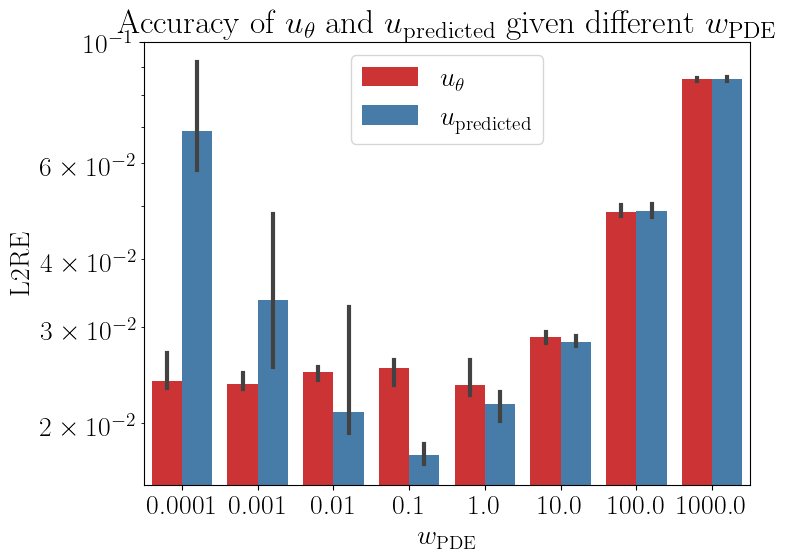

In [5]:
for var, subfolder in zip(variances, subfolders):

    save_dir = top_save_folder + f'var{var}/'

    errorS_uNN = np.load(save_dir + 'errorS_uNN.npy')
    errorS_u_reconstr = np.load(save_dir + 'errorS_u_reconstr.npy')
    errorS_uNN.reshape(len(w_PDEs), NumRep)
    errorS_u_reconstr.reshape(len(w_PDEs), NumRep)

    data = []
    for w_ind in range(len(w_PDEs)):
        pde_weight = w_PDEs[w_ind]
        for rep in range(NumRep):
            data.append([pde_weight, errorS_uNN[w_ind][rep], r'$u_{\theta}$'])
            data.append([pde_weight, errorS_u_reconstr[w_ind][rep], r'$u_{\mathrm{predicted}}$'])
    df = pd.DataFrame(data, columns=[r'$w_{\mathrm{PDE}}$', 'L2RE', 'Quantity'])

    fig, ax = plt.subplots(figsize=(8, 6))
    # MODIFIED: Set estimator to median and errorbar to 50% prediction interval (IQR)
    sns.barplot(
        x=r'$w_{\mathrm{PDE}}$',
        y='L2RE',
        hue='Quantity',
        data=df,
        ax=ax,
        palette=colors,
        estimator=np.median,  # Set bar height to the median
        errorbar=('pi', 50)   # Set error bars to 50% prediction interval (25th to 75th percentile)
    )
    # Optional: Adjust x-axis labels to be scientific notation for clarity
    ax.set_yscale('log')
    legend = ax.get_legend()
    legend.set_title('')
    ax.set_title(r'Accuracy of $u_{\theta}$ and $u_{\mathrm{predicted}}$ given different $w_{\mathrm{PDE}}$')
    fig.tight_layout()
    
    fig.savefig(save_dir + f'L2RE_uNN_u_reconstr{var}.svg', format='svg', bbox_inches='tight')



### Plot: u_NN, D_NN, and u_reconstr

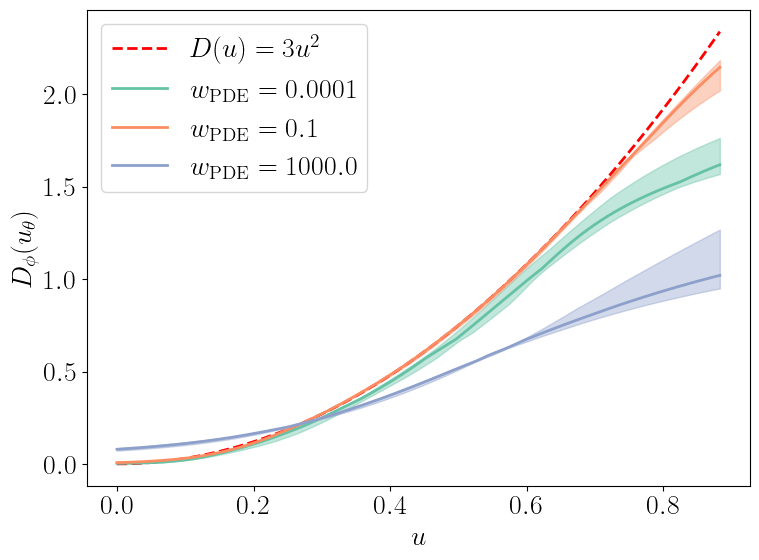

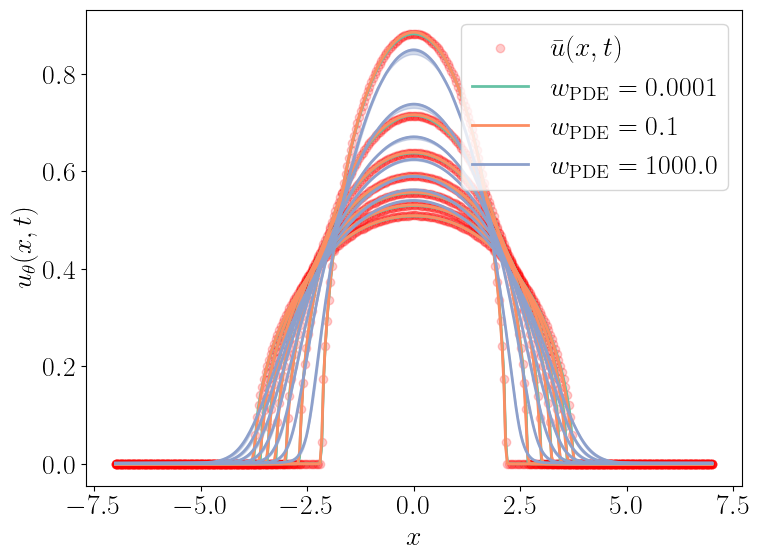

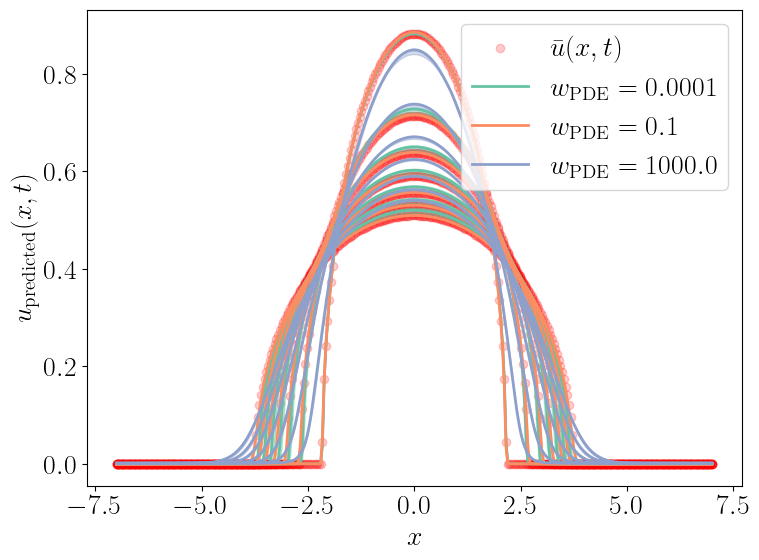

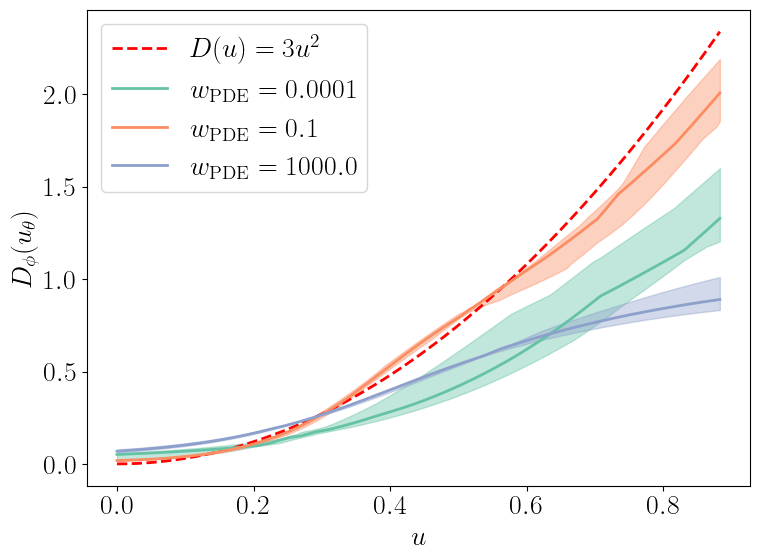

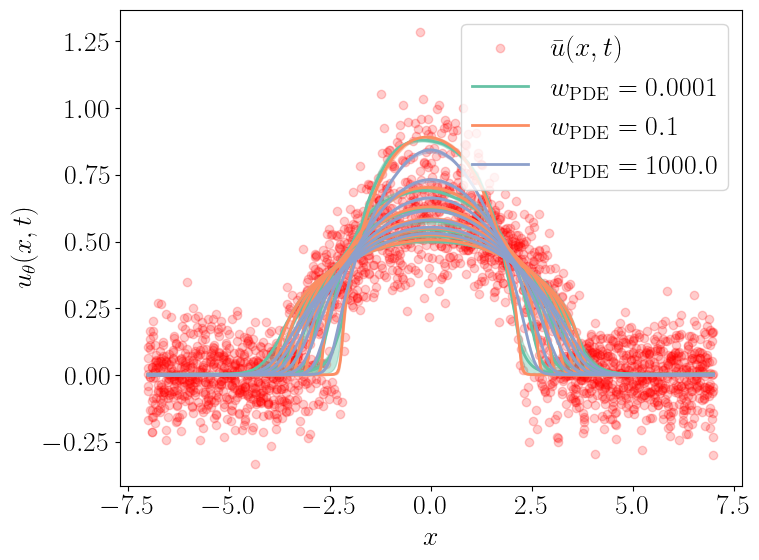

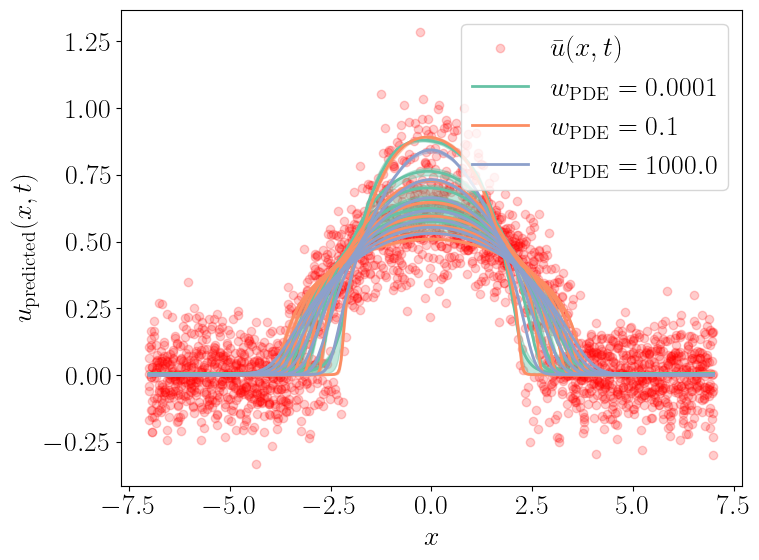

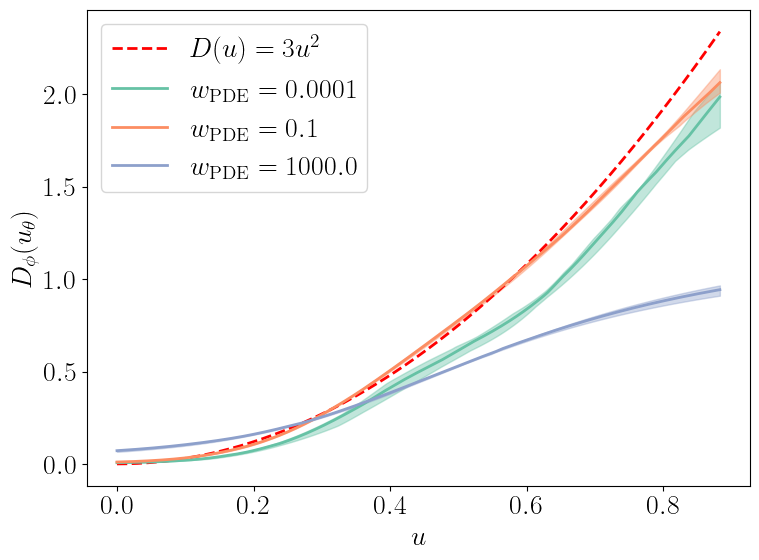

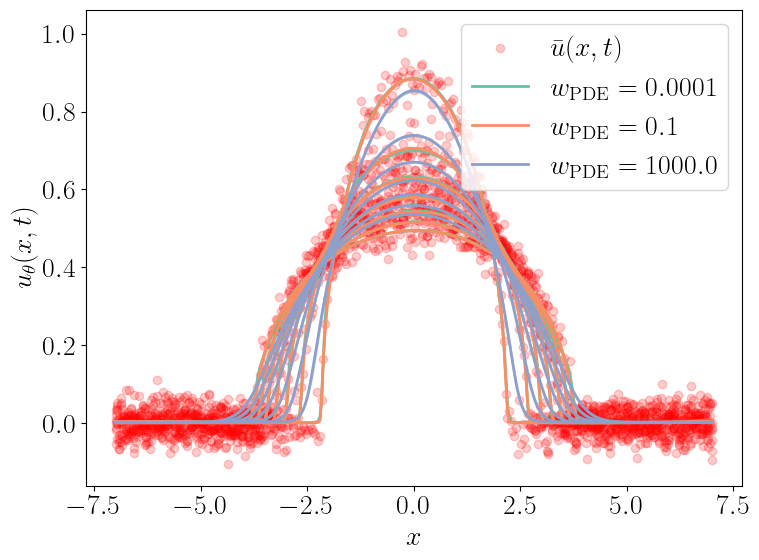

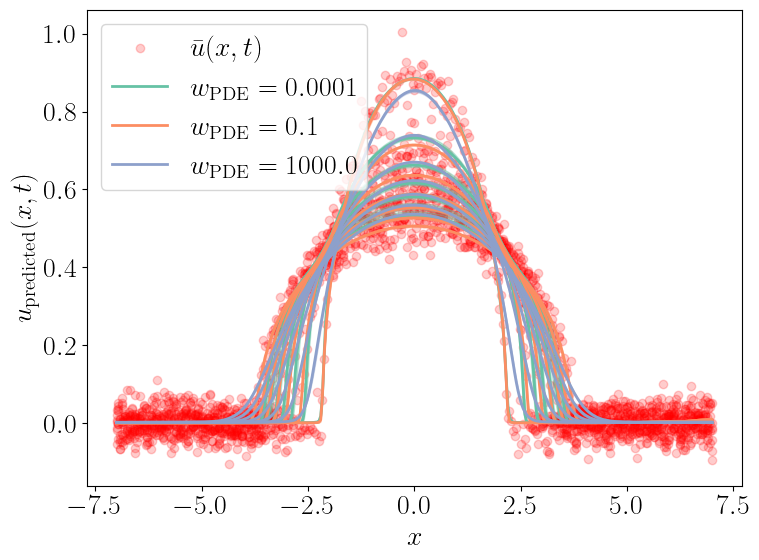

In [6]:
for var, subfolder in zip(variances, subfolders):

    save_dir = top_save_folder + f'var{var}/'
    load_dir = top_load_folder + subfolder

    u_reconstr_all = np.load(save_dir + 'u_reconstr_all.npy')

    noise_level = np.sqrt(var)
    np.random.seed(seed)
    additive_noise = noise_level * np.random.randn(*u_true.shape)
    u_noisy = u_true + additive_noise

   
    # Plot D_NN: 
    fig1, ax1 = plt.subplots(figsize=(8, 6))
    ax1.plot(U_grid, D_true, color='red', linestyle='--', label=r'$D(u)=3u^2$')
    for w_ind in range(len(w_PDEs1)):
        pde_weight = w_PDEs1[w_ind]
        test_D_pred_np_all = np.load(load_dir + f'data1.0_PDE{pde_weight}_BC0.0/D_predS.npy')
        D_learnt_median = np.median(test_D_pred_np_all, axis=0)
        D_learnt_q1 = np.percentile(test_D_pred_np_all, 25, axis=0)
        D_learnt_q3 = np.percentile(test_D_pred_np_all, 75, axis=0)
        ax1.plot(U_grid, D_learnt_median, color=colors1[w_ind], label=r'$w_{\mathrm{PDE}}=' + str(pde_weight) + '$')
        ax1.fill_between(U_grid, D_learnt_q1, D_learnt_q3, color=colors1[w_ind], alpha=alpha_val)
    ax1.set_xlabel(r'$u$')
    ax1.set_ylabel(r'$D_{\phi}(u_{\theta})$')
    ax1.legend(loc='best')

    # Plot u_NN and predicted u_NN:
    fig2, ax2 = plt.subplots(figsize=(8, 6))
    fig3, ax3 = plt.subplots(figsize=(8, 6))
    for t in range(Nt): # plot the noisy training data
        ax2.scatter(x_train, u_noisy[t, :], color='red', alpha=0.2, label=r'$\bar{u}(x, t)$' if t == 0 else None)
        ax3.scatter(x_train, u_noisy[t, :], color='red', alpha=0.2, label=r'$\bar{u}(x, t)$' if t == 0 else None)

    # load and plot
    color_index = 0
    for ind in indices:
        pde_weight = w_PDEs[ind]
        u_reconstr_S = u_reconstr_all[ind]
        u_reconstr_median, u_reconstr_q1, u_reconstr_q3 = np.median(u_reconstr_S, axis=0), np.percentile(u_reconstr_S, 25, axis=0), np.percentile(u_reconstr_S, 75, axis=0)
        u_NN_S = np.load(load_dir + f'data1.0_PDE{pde_weight}_BC0.0/u_predS.npy')
        u_NN_median, u_NN_q1, u_NN_q3 = np.median(u_NN_S, axis=0), np.percentile(u_NN_S, 25, axis=0), np.percentile(u_NN_S, 75, axis=0)

        for t in range(Nt):
            ax2.plot(x_train, u_NN_median[t, :], color=colors1[color_index], label=r'$w_{\mathrm{PDE}}=' + str(pde_weight) + '$' if t == 0 else None)
            ax2.fill_between(x_train, u_NN_q1[t, :], u_NN_q3[t, :], color=colors1[color_index], alpha=alpha_val)
            ax3.plot(x_train, u_reconstr_median[t, :], color=colors1[color_index], label=r'$w_{\mathrm{PDE}}=' + str(pde_weight) + '$' if t == 0 else None)
            ax3.fill_between(x_train, u_reconstr_q1[t, :], u_reconstr_q3[t, :], color=colors1[color_index], alpha=alpha_val)
        color_index += 1
    
    ax2.set_xlabel(r'$x$')
    ax2.set_ylabel(r'$u_{\theta}(x, t)$')
    ax2.legend(loc='best')
    ax3.set_xlabel(r'$x$')
    ax3.set_ylabel(r'$u_{\mathrm{predicted}}(x, t)$')
    ax3.legend(loc='best')

    fig1.tight_layout()
    fig2.tight_layout()
    fig3.tight_layout()

    
    fig1.savefig(save_dir + f'DNN_wPDE{pde_weight}_var{var}.svg', format='svg', bbox_inches='tight')
    fig2.savefig(save_dir + f'uNN_wPDE{pde_weight}_var{var}.svg', format='svg', bbox_inches='tight')
    fig3.savefig(save_dir + f'u_reconstr_wPDE{pde_weight}_var{var}.svg', format='svg', bbox_inches='tight')
